# Bài tập về nhà: Mạng Neural Network (ANN)

Họ và tên: Trần Bảo Nguyên

MSSV: 2001230587

---

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))
print(f"Device: {device}")

# Chuẩn bị sẵn dữ liệu
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

def train_simple(model, loader, criterion, optimizer, epochs=5):
    model.train()
    losses = []
    for epoch in range(epochs):
        running_loss = 0.0
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        avg_loss = running_loss / len(loader)
        losses.append(avg_loss)
        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")
    return losses

def evaluate_acc(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total

Device: cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 499kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.61MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.1MB/s]


### Bài 1: Sâu hơn có tốt hơn không?
So sánh model 1 lớp ẩn vs 2 lớp ẩn.

In [2]:
class Model1(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(nn.Flatten(), nn.Linear(784, 128), nn.ReLU(), nn.Linear(128, 10))
    def forward(self, x): return self.main(x)

class Model2(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(nn.Flatten(), nn.Linear(784, 256), nn.ReLU(), nn.Linear(256, 128), nn.ReLU(), nn.Linear(128, 10))
    def forward(self, x): return self.main(x)

m1, m2 = Model1().to(device), Model2().to(device)
print(f"Params M1: {sum(p.numel() for p in m1.parameters()):,}")
print(f"Params M2: {sum(p.numel() for p in m2.parameters()):,}")

print("Training Model 1...")
train_simple(m1, train_loader, nn.CrossEntropyLoss(), optim.Adam(m1.parameters(), lr=0.001))
print("Training Model 2...")
train_simple(m2, train_loader, nn.CrossEntropyLoss(), optim.Adam(m2.parameters(), lr=0.001))

print(f"Acc M1: {evaluate_acc(m1, test_loader)*100:.2f}%")
print(f"Acc M2: {evaluate_acc(m2, test_loader)*100:.2f}%")

Params M1: 101,770
Params M2: 235,146
Training Model 1...
Epoch 1/5, Loss: 0.2571
Epoch 2/5, Loss: 0.1103
Epoch 3/5, Loss: 0.0764
Epoch 4/5, Loss: 0.0582
Epoch 5/5, Loss: 0.0468
Training Model 2...
Epoch 1/5, Loss: 0.2334
Epoch 2/5, Loss: 0.0951
Epoch 3/5, Loss: 0.0649
Epoch 4/5, Loss: 0.0494
Epoch 5/5, Loss: 0.0401
Acc M1: 97.65%
Acc M2: 97.97%


### Bài 2: Ảnh hưởng của Learning Rate

Epoch 1/5, Loss: 0.2752
Epoch 2/5, Loss: 0.2029
Epoch 3/5, Loss: 0.1820
Epoch 4/5, Loss: 0.1841
Epoch 5/5, Loss: 0.1649
Epoch 1/5, Loss: 0.2594
Epoch 2/5, Loss: 0.1112
Epoch 3/5, Loss: 0.0775
Epoch 4/5, Loss: 0.0594
Epoch 5/5, Loss: 0.0470
Epoch 1/5, Loss: 0.5819
Epoch 2/5, Loss: 0.2746
Epoch 3/5, Loss: 0.2223
Epoch 4/5, Loss: 0.1883
Epoch 5/5, Loss: 0.1634


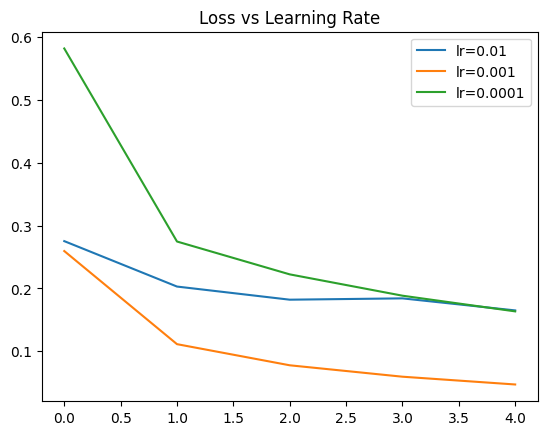

In [3]:
def train_with_lr(lr_value):
    model = Model1().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr_value)
    return train_simple(model, train_loader, criterion, optimizer, epochs=5)

lrs = [1e-2, 1e-3, 1e-4]
results = {lr: train_with_lr(lr) for lr in lrs}

for lr, losses in results.items():
    plt.plot(losses, label=f'lr={lr}')
plt.legend(); plt.title("Loss vs Learning Rate"); plt.show()

### Bài 3: Thêm Dropout

In [4]:
class ModelDropout(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 10))
    def forward(self, x): return self.main(x)

m_drop = ModelDropout().to(device)
train_simple(m_drop, train_loader, nn.CrossEntropyLoss(), optim.Adam(m_drop.parameters(), lr=0.001), epochs=10)
print(f"Train Acc: {evaluate_acc(m_drop, train_loader)*100:.2f}%")
print(f"Test Acc: {evaluate_acc(m_drop, test_loader)*100:.2f}%")

Epoch 1/10, Loss: 0.3156
Epoch 2/10, Loss: 0.1670
Epoch 3/10, Loss: 0.1337
Epoch 4/10, Loss: 0.1121
Epoch 5/10, Loss: 0.1014
Epoch 6/10, Loss: 0.0945
Epoch 7/10, Loss: 0.0859
Epoch 8/10, Loss: 0.0836
Epoch 9/10, Loss: 0.0771
Epoch 10/10, Loss: 0.0748
Train Acc: 98.97%
Test Acc: 97.73%


### Bài 4: Phân tích sai số theo từng lớp

In [5]:
m1.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        outputs = m1(images.to(device))
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
per_class_acc = cm.diagonal() / cm.sum(axis=1)
for i, acc in enumerate(per_class_acc):
    print(f"Class {i}: {acc*100:.2f}%")
print(f"Worst class: {np.argmin(per_class_acc)}")

Class 0: 98.88%
Class 1: 99.21%
Class 2: 98.45%
Class 3: 97.03%
Class 4: 97.86%
Class 5: 95.63%
Class 6: 98.12%
Class 7: 97.08%
Class 8: 97.23%
Class 9: 96.63%
Worst class: 5


### Bài 5: Trực quan hóa trọng số

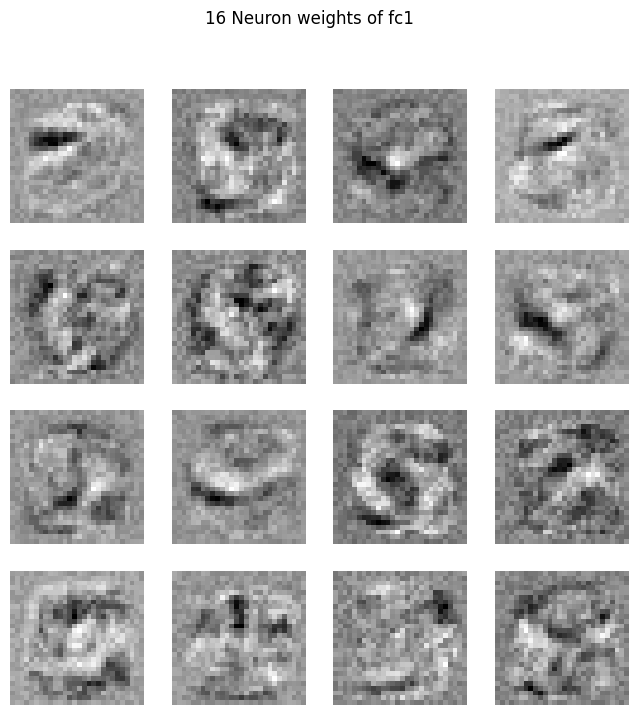

In [6]:
weights = m1.main[1].weight.detach().cpu() # Lấy Linear(784, 128)
plt.figure(figsize=(8, 8))
for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(weights[i].view(28, 28), cmap='gray')
    plt.axis('off')
plt.suptitle("16 Neuron weights of fc1")
plt.show()